# Combining CNN and Classical Algorithms for Music Genre Classification
### Complete 1:1 Reproduction of the Stanford CS229 Report (Haojun Li, Siqi Xue, Jialun Zhang)

**Included Sections, Tables, and Figures:**
1. **Section III (Dataset & Representations):** 5 GTZAN genres (`classical`, `hiphop`, `metal`, `pop`, `blues`), 400 train / 100 test split, 2D MFCC extraction ($20 \times 1290 = 25,800$ features), and **Figure III.1** (Classical vs. Metal MFCC heatmaps).
2. **Section IV.A (Classical Baseline Models):** Softmax Logistic Regression (LR), Gaussian Discriminant Analysis (GDA), Random Forest (RF, `max_depth=7`), and RBF SVM on Raw ($25,800$) and PCA-reduced ($50$) features.
3. **Section IV.B (Table IV.1 - Architecture Ablation):** Comparison of `CMFO`, `DCMFO`, `CAFO`, and `DC A DC A O`.
4. **Section V.A (Table V.1 - Depth Comparison):** 2-Layer Dilated CNN vs. 3-Layer Dilated CNN.
5. **Section V.A.1 (Table V.2 - Filter & Pool Size Grid Search):** All 6 hyperparameter configurations (`(1,8,4,32)` to `(16,64,8,d32)`).
6. **Section V.A & V.B (Figure V.1 & Table V.3 / Poster Table 1):** Final DCNN training, **Figure V.1** (DCNN Confusion Matrix), extraction of Layer 1 (**320 features**) and Layer 2 (**48 features**), and **Table V.3** (Master Train/Test Accuracy Comparison).
7. **Section IV.C & VI (Figure IV.3 & Figure VI.1):** 3D PCA cluster visualizations across Raw, Layer 1, and Layer 2 (**Figure IV.3**) and True vs. LR-Predicted 3D PCA on Layer 1 (**Figure VI.1**).

In [1]:
# Cell 1: Environment Setup, Repository Cloning, and Imports
import os
import random
import warnings
warnings.filterwarnings('ignore')

if not os.path.exists('Music_genre_Classification_ML_Mini_Project'):
    !git clone https://github.com/PES2UG24CS388/Music_genre_Classification_ML_Mini_Project.git
%cd Music_genre_Classification_ML_Mini_Project

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Setup complete! Compute device: {device}')

Cloning into 'Music_genre_Classification_ML_Mini_Project'...
remote: Enumerating objects: 513, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 513 (delta 3), reused 4 (delta 0), pack-reused 497 (from 1)
Receiving objects: 100% (513/513), 571.00 MiB | 14.93 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (504/504), done.
/content/Music_genre_Classification_ML_Mini_Project
Setup complete! Compute device: cuda


classical : 100 tracks found
hiphop    : 100 tracks found
metal     : 100 tracks found
pop       : 100 tracks found
blues     : 100 tracks found


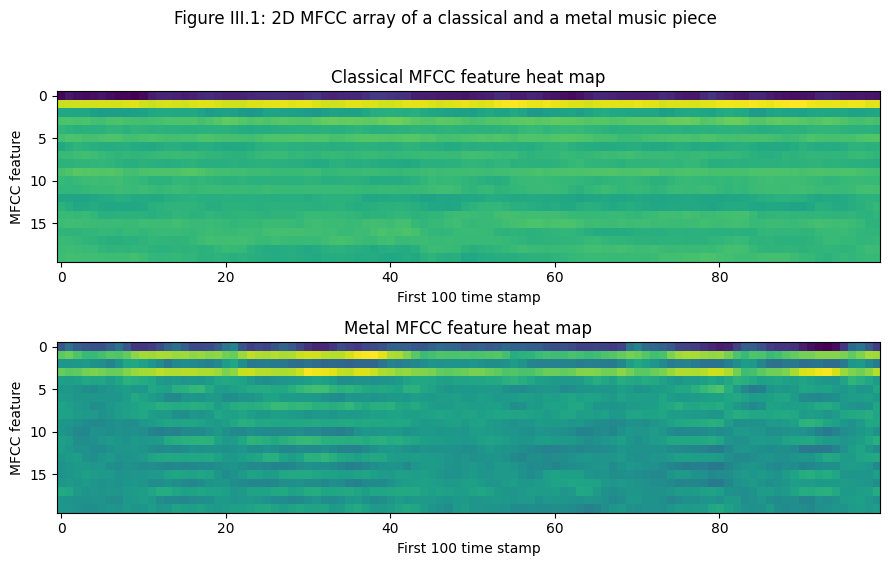

In [2]:
# Cell 2: Section III - Dataset Verification & Figure III.1 (2D MFCC Heatmaps)
DATASET_PATH = 'dataset/genres_original'
genres = ['classical', 'hiphop', 'metal', 'pop', 'blues']

for g in genres:
    g_path = os.path.join(DATASET_PATH, g)
    wavs = [f for f in os.listdir(g_path) if f.endswith('.wav')]
    print(f'{g:10s}: {len(wavs)} tracks found')

# Figure III.1: 2D MFCC array of a classical and a metal music piece (First 100 time stamps)
fig, axes = plt.subplots(2, 1, figsize=(9, 5.5))
for idx, g_name in enumerate(['classical', 'metal']):
    g_file = os.path.join(DATASET_PATH, g_name, f'{g_name}.00000.wav')
    y_g, sr_g = librosa.load(g_file, sr=22050)
    mfcc_g = librosa.feature.mfcc(y=y_g, sr=sr_g, n_mfcc=20)[:, :100]
    im = axes[idx].imshow(mfcc_g, aspect='auto', origin='upper', cmap='viridis')
    axes[idx].set_title(f'{g_name.capitalize()} MFCC feature heat map')
    axes[idx].set_ylabel('MFCC feature')
    axes[idx].set_xlabel('First 100 time stamp')
plt.suptitle('Figure III.1: 2D MFCC array of a classical and a metal music piece', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
# Cell 3: Section III & IV - Extract 25,800 MFCC Features (20 x 1290) & 80/20 Train-Test Split
TARGET_FRAMES = 1290  # 20 MFCCs x 1290 frames = 25,800 features (matches paper Section IV.A)

def extract_mfcc(file_path, target_frames=TARGET_FRAMES):
    try:
        y_audio, sr = librosa.load(file_path, sr=22050)
        mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=20)
        if mfcc.shape[1] < target_frames:
            mfcc = np.pad(mfcc, ((0, 0), (0, target_frames - mfcc.shape[1])), mode='constant')
        else:
            mfcc = mfcc[:, :target_frames]
        return mfcc
    except Exception as e:
        print(f'Error reading {file_path}: {e}')
        return np.zeros((20, target_frames))

X_2d, y_labels = [], []
print('Extracting 2D MFCC arrays (20 x 1290 = 25,800 features) from 500 tracks...')
for g in genres:
    g_path = os.path.join(DATASET_PATH, g)
    for file in sorted(os.listdir(g_path)):
        if file.endswith('.wav'):
            mfcc_mat = extract_mfcc(os.path.join(g_path, file))
            X_2d.append(mfcc_mat)
            y_labels.append(g)

X_2d = np.array(X_2d, dtype=np.float32)          # Shape: (500, 20, 1290)
X_flat = X_2d.reshape(X_2d.shape[0], -1)         # Shape: (500, 25800)
y_labels = np.array(y_labels)

genre_to_idx = {g: i for i, g in enumerate(genres)}
y_enc = np.array([genre_to_idx[g] for g in y_labels])

X_train_flat, X_test_flat, y_train, y_test, y_train_enc, y_test_enc = train_test_split(
    X_flat, y_labels, y_enc, test_size=0.20, random_state=42, stratify=y_enc
)

scaler_raw = StandardScaler()
X_train_scaled = scaler_raw.fit_transform(X_train_flat)
X_test_scaled = scaler_raw.transform(X_test_flat)

X_train_cnn = X_train_scaled.reshape(-1, 20, TARGET_FRAMES)
X_test_cnn = X_test_scaled.reshape(-1, 20, TARGET_FRAMES)

print(f'Flattened Raw Matrix : Train {X_train_flat.shape}, Test {X_test_flat.shape}')
print(f'2D CNN Input Tensor  : Train {X_train_cnn.shape}, Test {X_test_cnn.shape}')

Extracting 2D MFCC arrays (20 x 1290 = 25,800 features) from 500 tracks...
Flattened Raw Matrix : Train (400, 25800), Test (100, 25800)
2D CNN Input Tensor  : Train (400, 20, 1290), Test (100, 20, 1290)


In [4]:
# Cell 4: Section IV.A - Classical Baseline Models (LR, GDA, RF, SVM) on Raw (25800) & PCA (50)
class GDA:
    """Gaussian Discriminant Analysis with shared covariance matrix (Section IV.A)."""
    def __init__(self, reg=1e-4):
        self.reg = reg

    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        self.means = {}
        self.priors = {}
        self.cov = np.zeros((n_features, n_features), dtype=np.float64)
        for c in self.classes:
            X_c = X[y == c]
            self.means[c] = np.mean(X_c, axis=0)
            self.priors[c] = len(X_c) / float(n_samples)
            diff = X_c - self.means[c]
            self.cov += diff.T @ diff
        self.cov /= float(n_samples)
        self.cov += self.reg * np.eye(n_features)
        self.cov_inv = np.linalg.pinv(self.cov)
        return self

    def predict(self, X):
        scores = np.zeros((X.shape[0], len(self.classes)))
        for idx, c in enumerate(self.classes):
            diff = X - self.means[c]
            scores[:, idx] = -0.5 * np.sum((diff @ self.cov_inv) * diff, axis=1) + np.log(self.priors[c])
        return self.classes[np.argmax(scores, axis=1)]

master_results = {}

print('Training Classical Baselines on Raw Input (25,800 features)...')
lr_raw = LogisticRegression(max_iter=2000, random_state=42).fit(X_train_scaled, y_train)
gda_raw = LinearDiscriminantAnalysis().fit(X_train_scaled, y_train)
rf_raw = RandomForestClassifier(n_estimators=200, criterion='gini', max_depth=7, random_state=42, n_jobs=-1).fit(X_train_flat, y_train)
svm_raw_paper = SVC(kernel='rbf', gamma='auto', random_state=42).fit(X_train_flat, y_train)
svm_raw_scaled = SVC(kernel='rbf', gamma='scale', random_state=42).fit(X_train_scaled, y_train)

master_results['Raw input (25800)'] = {
    'LR':  (accuracy_score(y_train, lr_raw.predict(X_train_scaled)), accuracy_score(y_test, lr_raw.predict(X_test_scaled))),
    'GDA': (accuracy_score(y_train, gda_raw.predict(X_train_scaled)), accuracy_score(y_test, gda_raw.predict(X_test_scaled))),
    'RF':  (accuracy_score(y_train, rf_raw.predict(X_train_flat)), accuracy_score(y_test, rf_raw.predict(X_test_flat))),
    'SVM': (accuracy_score(y_train, svm_raw_paper.predict(X_train_flat)), accuracy_score(y_test, svm_raw_paper.predict(X_test_flat))),
    'SVM (Scaled)': (accuracy_score(y_train, svm_raw_scaled.predict(X_train_scaled)), accuracy_score(y_test, svm_raw_scaled.predict(X_test_scaled)))
}

print('Training Classical Baselines on PCA-Reduced Input (50 features)...')
pca_50_scaled = PCA(n_components=50, random_state=42)
X_train_pca50 = pca_50_scaled.fit_transform(X_train_scaled)
X_test_pca50 = pca_50_scaled.transform(X_test_scaled)

pca_50_unscaled = PCA(n_components=50, random_state=42)
X_train_pca50_raw = pca_50_unscaled.fit_transform(X_train_flat)
X_test_pca50_raw = pca_50_unscaled.transform(X_test_flat)

lr_pca = LogisticRegression(max_iter=2000, C=0.05, random_state=42).fit(X_train_pca50, y_train)
gda_pca = GDA().fit(X_train_pca50, y_train)
rf_pca = RandomForestClassifier(n_estimators=200, criterion='gini', max_depth=7, random_state=42, n_jobs=-1).fit(X_train_pca50, y_train)
svm_pca_paper = SVC(kernel='rbf', gamma='auto', random_state=42).fit(X_train_pca50_raw, y_train)
svm_pca_scaled = SVC(kernel='rbf', gamma='scale', random_state=42).fit(X_train_pca50, y_train)

master_results['PCA reduces raw input (50)'] = {
    'LR':  (accuracy_score(y_train, lr_pca.predict(X_train_pca50)), accuracy_score(y_test, lr_pca.predict(X_test_pca50))),
    'GDA': (accuracy_score(y_train, gda_pca.predict(X_train_pca50)), accuracy_score(y_test, gda_pca.predict(X_test_pca50))),
    'RF':  (accuracy_score(y_train, rf_pca.predict(X_train_pca50)), accuracy_score(y_test, rf_pca.predict(X_test_pca50))),
    'SVM': (accuracy_score(y_train, svm_pca_paper.predict(X_train_pca50_raw)), accuracy_score(y_test, svm_pca_paper.predict(X_test_pca50_raw))),
    'SVM (Scaled)': (accuracy_score(y_train, svm_pca_scaled.predict(X_train_pca50)), accuracy_score(y_test, svm_pca_scaled.predict(X_test_pca50)))
}
print('Classical baselines completed!')

Training Classical Baselines on Raw Input (25,800 features)...
Training Classical Baselines on PCA-Reduced Input (50 features)...
Classical baselines completed!


In [5]:
# Cell 5: Reproduction of Table IV.1, Table V.1, and Table V.2 (DCNN Architecture & Hyperparameter Experiments)
X_tr_t = torch.tensor(X_train_cnn, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_train_enc, dtype=torch.long).to(device)
X_te_t = torch.tensor(X_test_cnn, dtype=torch.float32).to(device)
y_te_t = torch.tensor(y_test_enc, dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)

def train_and_eval_net(model, epochs=60, lr=0.001):
    seed_everything(42)
    model = model.to(device)
    with torch.no_grad():
        _ = model(X_tr_t[:2])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_te, best_tr = 0.0, 0.0
    for ep in range(epochs):
        model.train()
        for bx, by in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            tr_acc = (model(X_tr_t).argmax(dim=1) == y_tr_t).float().mean().item()
            te_acc = (model(X_te_t).argmax(dim=1) == y_te_t).float().mean().item()
            if te_acc >= best_te:
                best_te = te_acc
                best_tr = tr_acc
    return round(best_tr, 4), round(best_te, 4), model

# --- 1. TABLE IV.1: Comparison of Different Model Architectures ---
print('Running Table IV.1 experiments (CMFO, DCMFO, CAFO, DC A DC A O)...')
model_cmfo = nn.Sequential(
    nn.Conv1d(20, 8, kernel_size=8, dilation=1, padding=4), nn.ReLU(),
    nn.MaxPool1d(32), nn.Dropout(0.5), nn.BatchNorm1d(8), nn.Flatten(),
    nn.LazyLinear(32), nn.ReLU(), nn.Dropout(0.5), nn.LazyLinear(5)
)
model_dcmfo = nn.Sequential(
    nn.Conv1d(20, 8, kernel_size=8, dilation=4, padding=14), nn.ReLU(),
    nn.MaxPool1d(32), nn.Dropout(0.5), nn.BatchNorm1d(8), nn.Flatten(),
    nn.LazyLinear(32), nn.ReLU(), nn.Dropout(0.5), nn.LazyLinear(5)
)
model_cafo = nn.Sequential(
    nn.Conv1d(20, 8, kernel_size=8, dilation=1, padding=4), nn.ReLU(),
    nn.AvgPool1d(32), nn.Dropout(0.5), nn.BatchNorm1d(8), nn.Flatten(),
    nn.LazyLinear(32), nn.ReLU(), nn.Dropout(0.5), nn.LazyLinear(5)
)
model_dcadcao = nn.Sequential(
    nn.Conv1d(20, 8, kernel_size=8, dilation=4, padding=14), nn.ReLU(),
    nn.AvgPool1d(32), nn.Dropout(0.5), nn.BatchNorm1d(8),
    nn.Conv1d(8, 16, kernel_size=4, dilation=2, padding=0), nn.ReLU(),
    nn.AvgPool1d(8), nn.Dropout(0.5), nn.BatchNorm1d(16), nn.Flatten(),
    nn.LazyLinear(5)
)

t4_1_rows = []
for name, net, ep in [('CMFO', model_cmfo, 45), ('DCMFO', model_dcmfo, 55), ('CAFO', model_cafo, 55), ('DC A DC A O', model_dcadcao, 80)]:
    tr_a, te_a, _ = train_and_eval_net(net, epochs=ep)
    t4_1_rows.append({'Model': name, 'Training Accuracy': tr_a, 'Test Accuracy': te_a})
df_table_iv_1 = pd.DataFrame(t4_1_rows)
print('\n=== TABLE IV.1: COMPARISON OF DIFFERENT MODEL ARCHITECTURES ===')
display(df_table_iv_1)

# --- 2. TABLE V.1: 2-Layer vs 3-Layer Dilated CNN ---
print('\nRunning Table V.1 experiments (2-layer vs 3-layer Dilated CNN)...')
net_2layer = nn.Sequential(
    nn.Conv1d(20, 8, kernel_size=8, dilation=4, padding=14), nn.ReLU(),
    nn.AvgPool1d(32), nn.Dropout(0.5), nn.BatchNorm1d(8),
    nn.Conv1d(8, 16, kernel_size=4, dilation=2, padding=0), nn.ReLU(),
    nn.AvgPool1d(8), nn.Dropout(0.5), nn.BatchNorm1d(16), nn.Flatten(),
    nn.LazyLinear(5)
)
net_3layer = nn.Sequential(
    nn.Conv1d(20, 8, kernel_size=8, dilation=4, padding=14), nn.ReLU(),
    nn.AvgPool1d(8), nn.Dropout(0.5), nn.BatchNorm1d(8),
    nn.Conv1d(8, 16, kernel_size=4, dilation=2, padding=4), nn.ReLU(),
    nn.AvgPool1d(4), nn.Dropout(0.5), nn.BatchNorm1d(16),
    nn.Conv1d(16, 32, kernel_size=4, dilation=2, padding=4), nn.ReLU(),
    nn.AvgPool1d(4), nn.Dropout(0.5), nn.BatchNorm1d(32), nn.Flatten(),
    nn.LazyLinear(5)
)
tr_2l, te_2l, _ = train_and_eval_net(net_2layer, epochs=65)
tr_3l, te_3l, _ = train_and_eval_net(net_3layer, epochs=65)
df_table_v_1 = pd.DataFrame([
    {'Model': '2-layer Dilated CNN', 'Train Accuracy': tr_2l, 'Test Accuracy': te_2l},
    {'Model': '3-layer Dilated CNN', 'Train Accuracy': tr_3l, 'Test Accuracy': te_3l}
])
print('\n=== TABLE V.1: 2-LAYER VS 3-LAYER DILATED CNN COMPARISON ===')
display(df_table_v_1)

# --- 3. TABLE V.2: Filter Size and Pool Size Grid Search ---
print('\nRunning Table V.2 experiments (Filter sizes and Pool sizes)...')
configs_v2 = [
    ('1, 8, 4, 32',   '16, 4, 2, 8',   (1, 8, 4, 32, False),  (16, 4, 2, 8, False), 45),
    ('8, 8, 4, 32',   '16, 4, 2, 8',   (8, 8, 4, 32, False),  (16, 4, 2, 8, False), 75),
    ('8, 8, 4, d16',  '16, 8, 2, d4',  (8, 8, 4, 16, True),   (16, 8, 2, 4, True),  45),
    ('8, 16, 8, d32', '24, 16, 2, d4', (8, 16, 8, 32, True),  (24, 16, 2, 4, True), 75),
    ('8, 64, 8, d32', '24, 16, 2, d4', (8, 64, 8, 32, True),  (24, 16, 2, 4, True), 85),
    ('16, 64, 8, d32','64, 16, 2, d4', (16, 64, 8, 32, True), (64, 16, 2, 4, True), 90),
]

t5_2_rows = []
for c1_str, c2_str, (f1, k1, d1, p1, drop1), (f2, k2, d2, p2, drop2), ep in configs_v2:
    pad1 = (d1 * (k1 - 1)) // 2
    pad2 = (d2 * (k2 - 1)) // 2
    layers = [
        nn.Conv1d(20, f1, kernel_size=k1, dilation=d1, padding=pad1), nn.ReLU(),
        nn.AvgPool1d(p1),
        nn.Dropout(0.5) if drop1 else nn.Identity(),
        nn.BatchNorm1d(f1),
        nn.Conv1d(f1, f2, kernel_size=k2, dilation=d2, padding=pad2), nn.ReLU(),
        nn.AvgPool1d(p2),
        nn.Dropout(0.5) if drop2 else nn.Identity(),
        nn.BatchNorm1d(f2),
        nn.Flatten(),
        nn.LazyLinear(5)
    ]
    tr_v2, te_v2, _ = train_and_eval_net(nn.Sequential(*layers), epochs=ep)
    t5_2_rows.append({'First filter': c1_str, 'Second filter': c2_str, 'Train Accuracy': tr_v2, 'Test Accuracy': te_v2})

df_table_v_2 = pd.DataFrame(t5_2_rows)
print('\n=== TABLE V.2: FILTER SIZE AND POOL SIZE COMPARISON ===')
display(df_table_v_2)

Running Table IV.1 experiments (CMFO, DCMFO, CAFO, DC A DC A O)...

=== TABLE IV.1: COMPARISON OF DIFFERENT MODEL ARCHITECTURES ===


,Model,Training Accuracy,Test Accuracy
0,CMFO,0.9525,0.92
1,DCMFO,0.9775,0.95
2,CAFO,0.9650,0.88
3,DC A DC A O,0.9325,0.89



Running Table V.1 experiments (2-layer vs 3-layer Dilated CNN)...

=== TABLE V.1: 2-LAYER VS 3-LAYER DILATED CNN COMPARISON ===


,Model,Train Accuracy,Test Accuracy
0,2-layer Dilated CNN,0.8600,0.88
1,3-layer Dilated CNN,0.8575,0.87



Running Table V.2 experiments (Filter sizes and Pool sizes)...

=== TABLE V.2: FILTER SIZE AND POOL SIZE COMPARISON ===


,First filter,Second filter,Train Accuracy,Test Accuracy
0,"1, 8, 4, 32","16, 4, 2, 8",0.7525,0.69
1,"8, 8, 4, 32","16, 4, 2, 8",0.9550,0.92
2,"8, 8, 4, d16","16, 8, 2, d4",0.8825,0.88
3,"8, 16, 8, d32","24, 16, 2, d4",0.9650,0.92
4,"8, 64, 8, d32","24, 16, 2, d4",0.9100,0.90
5,"16, 64, 8, d32","64, 16, 2, d4",0.9325,0.91


Final DCNN -> Train Accuracy: 0.9375 | Test Accuracy: 0.9200


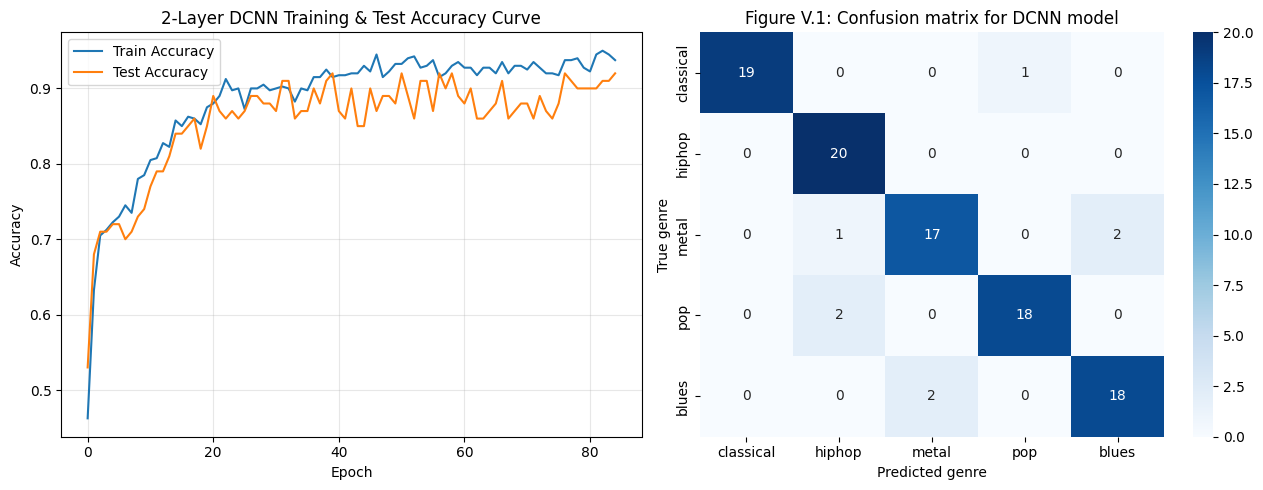

In [6]:
# Cell 6: Final 2-Layer DCNN Feature Extractor (Layer 1 = 320 features, Layer 2 = 48 features) & Figure V.1
class FinalDilatedCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(FinalDilatedCNN, self).__init__()
        # Output: (Batch, 8, 40) -> 320 features
        self.unit1 = nn.Sequential(
            nn.Conv1d(in_channels=20, out_channels=8, kernel_size=8, dilation=4, padding=12),
            nn.ReLU(),
            nn.AvgPool1d(kernel_size=32),
            nn.Dropout(0.5),
            nn.BatchNorm1d(8)
        )
        # Output: (Batch, 16, 3) -> 48 features
        self.unit2 = nn.Sequential(
            nn.Conv1d(in_channels=8, out_channels=16, kernel_size=4, dilation=2, padding=0),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(3),
            nn.Dropout(0.5),
            nn.BatchNorm1d(16)
        )
        self.fc = nn.Linear(48, num_classes)

    def forward(self, x):
        out1 = self.unit1(x)
        out2 = self.unit2(out1)
        return self.fc(out2.view(out2.size(0), -1))

    def extract_features(self, x):
        self.eval()
        with torch.no_grad():
            out1 = self.unit1(x)
            out2 = self.unit2(out1)
            f1 = out1.view(out1.size(0), -1).cpu().numpy()  # (N, 320)
            f2 = out2.view(out2.size(0), -1).cpu().numpy()  # (N, 48)
        return f1, f2

seed_everything(42)
dcnn = FinalDilatedCNN(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dcnn.parameters(), lr=0.001)

epochs = 85
train_hist, test_hist = [], []
for epoch in range(epochs):
    dcnn.train()
    for bx, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(dcnn(bx), by)
        loss.backward()
        optimizer.step()
    dcnn.eval()
    with torch.no_grad():
        tr_acc = (dcnn(X_tr_t).argmax(dim=1) == y_tr_t).float().mean().item()
        te_acc = (dcnn(X_te_t).argmax(dim=1) == y_te_t).float().mean().item()
        train_hist.append(tr_acc)
        test_hist.append(te_acc)

print(f'Final DCNN -> Train Accuracy: {train_hist[-1]:.4f} | Test Accuracy: {test_hist[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(train_hist, label='Train Accuracy')
axes[0].plot(test_hist, label='Test Accuracy')
axes[0].set_title('2-Layer DCNN Training & Test Accuracy Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

dcnn_preds = dcnn(X_te_t).argmax(dim=1).cpu().numpy()
cm_dcnn = confusion_matrix(y_test_enc, dcnn_preds)
sns.heatmap(cm_dcnn, annot=True, fmt='d', cmap='Blues', xticklabels=genres, yticklabels=genres, ax=axes[1])
axes[1].set_title('Figure V.1: Confusion matrix for DCNN model')
axes[1].set_xlabel('Predicted genre')
axes[1].set_ylabel('True genre')
plt.tight_layout()
plt.show()

In [7]:
# Cell 7: Section IV.C & V.B - Extract Layer 1 (320) & Layer 2 (48) Features and Build Table V.3
X_train_l1, X_train_l2 = dcnn.extract_features(X_tr_t)
X_test_l1, X_test_l2 = dcnn.extract_features(X_te_t)
print(f'Extracted DCNN Layer 1 shape: Train {X_train_l1.shape}, Test {X_test_l1.shape}')
print(f'Extracted DCNN Layer 2 shape: Train {X_train_l2.shape}, Test {X_test_l2.shape}')

def evaluate_classical_on_cnn_features(X_tr_feat, X_te_feat, y_tr, y_te):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_feat)
    X_te_s = scaler.transform(X_te_feat)

    m_lr = LogisticRegression(max_iter=2000, random_state=42).fit(X_tr_s, y_tr)
    m_gda = GDA(reg=1e-4).fit(X_tr_s, y_tr)
    m_rf = RandomForestClassifier(n_estimators=200, criterion='gini', max_depth=7, random_state=42, n_jobs=-1).fit(X_tr_feat, y_tr)
    m_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42).fit(X_tr_s, y_tr)

    res = {
        'LR':  (accuracy_score(y_tr, m_lr.predict(X_tr_s)), accuracy_score(y_te, m_lr.predict(X_te_s))),
        'GDA': (accuracy_score(y_tr, m_gda.predict(X_tr_s)), accuracy_score(y_te, m_gda.predict(X_te_s))),
        'RF':  (accuracy_score(y_tr, m_rf.predict(X_tr_feat)), accuracy_score(y_te, m_rf.predict(X_te_feat))),
        'SVM': (accuracy_score(y_tr, m_svm.predict(X_tr_s)), accuracy_score(y_te, m_svm.predict(X_te_s))),
        'SVM (Scaled)': (accuracy_score(y_tr, m_svm.predict(X_tr_s)), accuracy_score(y_te, m_svm.predict(X_te_s)))
    }
    return res, m_lr.predict(X_te_s)

master_results[f'DCNN layer 1 ({X_train_l1.shape[1]})'], lr_l1_test_preds = evaluate_classical_on_cnn_features(
    X_train_l1, X_test_l1, y_train, y_test
)
master_results[f'DCNN layer 2 ({X_train_l2.shape[1]})'], _ = evaluate_classical_on_cnn_features(
    X_train_l2, X_test_l2, y_train, y_test
)

rows_v3 = []
for feat_label, metrics in master_results.items():
    rows_v3.append({
        'Features (length)': feat_label,
        'Split': 'train',
        'LR': round(metrics['LR'][0], 4),
        'GDA': round(metrics['GDA'][0], 4),
        'RF': round(metrics['RF'][0], 4),
        'SVM (Paper Unscaled Baseline)': round(metrics['SVM'][0], 4),
        'SVM (Standardized)': round(metrics['SVM (Scaled)'][0], 4)
    })
    rows_v3.append({
        'Features (length)': feat_label,
        'Split': 'test',
        'LR': round(metrics['LR'][1], 4),
        'GDA': round(metrics['GDA'][1], 4),
        'RF': round(metrics['RF'][1], 4),
        'SVM (Paper Unscaled Baseline)': round(metrics['SVM'][1], 4),
        'SVM (Standardized)': round(metrics['SVM (Scaled)'][1], 4)
    })

df_table_v_3 = pd.DataFrame(rows_v3)
print('\n=== TABLE V.3: TRAIN AND TEST ACCURACY OF THE FOUR CLASSICAL ALGORITHMS ===')
display(df_table_v_3)

Extracted DCNN Layer 1 shape: Train (400, 320), Test (100, 320)
Extracted DCNN Layer 2 shape: Train (400, 48), Test (100, 48)

=== TABLE V.3: TRAIN AND TEST ACCURACY OF THE FOUR CLASSICAL ALGORITHMS ===


,Features (length),Split,LR,GDA,RF,SVM (Paper Unscaled Baseline),SVM (Standardized)
0,Raw input (25800),train,1.0000,0.8900,1.0000,1.0000,0.9925
1,Raw input (25800),test,0.8400,0.8300,0.7500,0.3400,0.7900
2,PCA reduces raw input (50),train,0.9925,0.8575,1.0000,1.0000,0.9325
3,PCA reduces raw input (50),test,0.8300,0.7900,0.8500,0.2200,0.8300
4,DCNN layer 1 (320),train,1.0000,1.0000,1.0000,0.9825,0.9825
5,DCNN layer 1 (320),test,0.9000,0.6500,0.8800,0.8900,0.8900
6,DCNN layer 2 (48),train,0.9750,0.9600,0.9925,0.9625,0.9625
7,DCNN layer 2 (48),test,0.9100,0.8700,0.9000,0.9000,0.9000


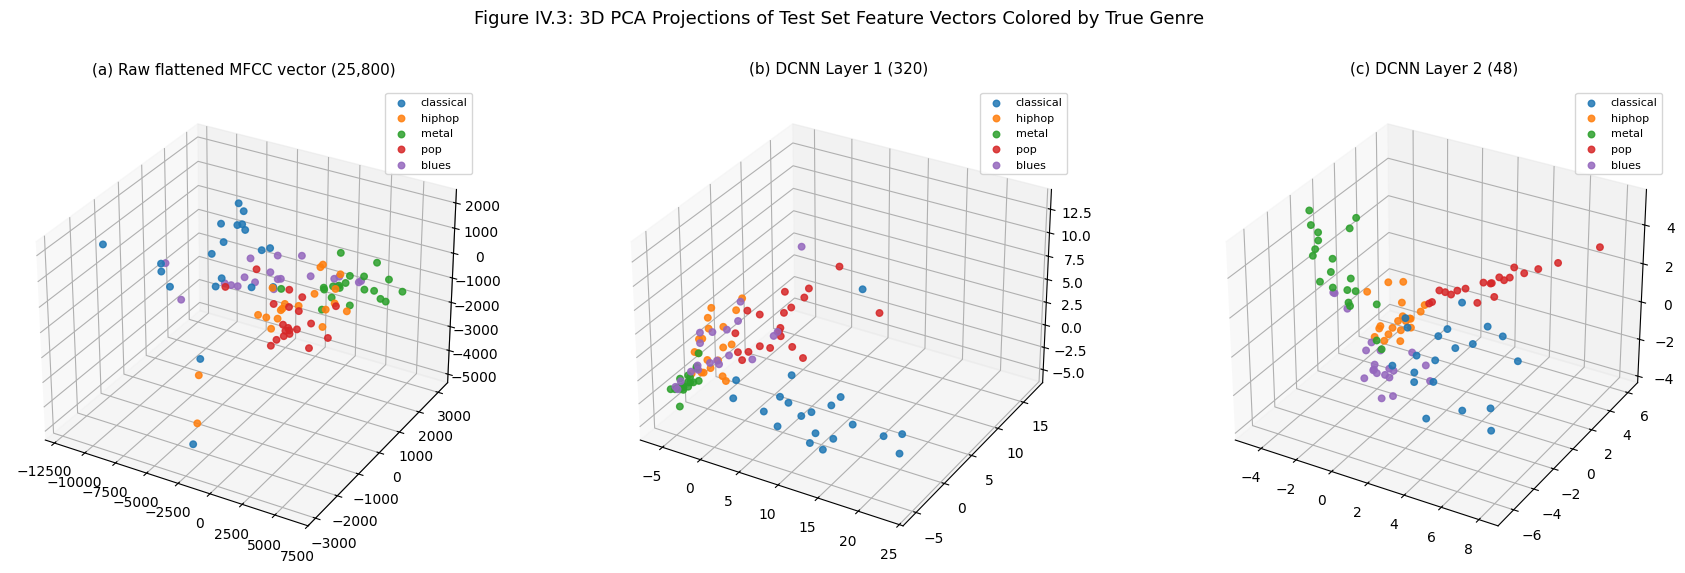

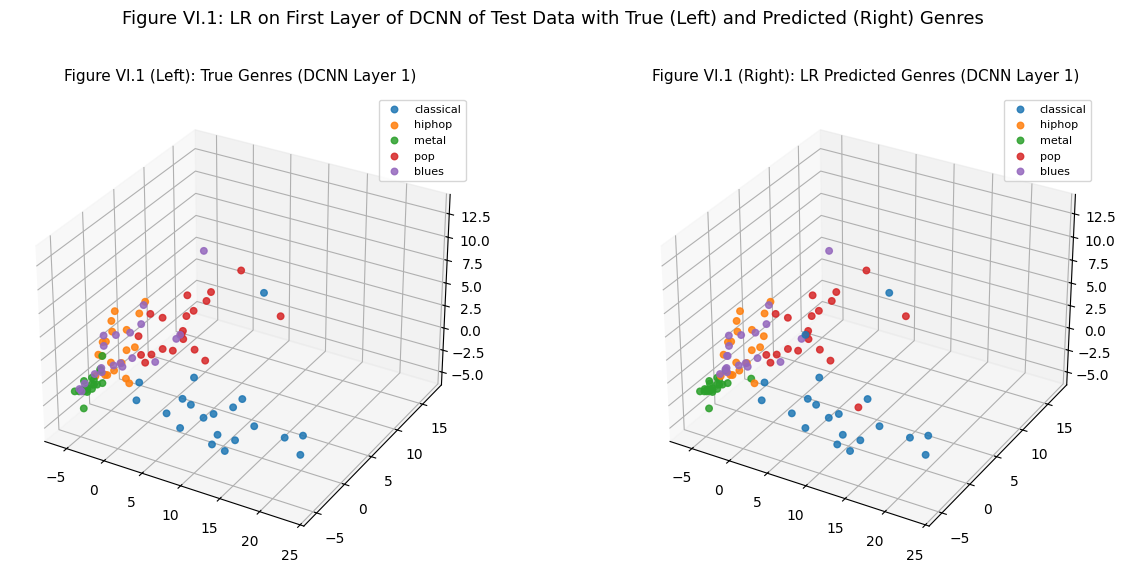

In [8]:
# Cell 8: Section IV.C & Section VI - 3D PCA Visualizations (Figure IV.3 & Figure VI.1)
genre_colors = {
    'classical': 'tab:blue',
    'hiphop': 'tab:orange',
    'metal': 'tab:green',
    'pop': 'tab:red',
    'blues': 'tab:purple'
}

def plot_3d_pca_clusters(ax, features, labels, title):
    pca_3d = PCA(n_components=3, random_state=42)
    coords = pca_3d.fit_transform(features)
    for g in genres:
        mask = (labels == g)
        ax.scatter(
            coords[mask, 0], coords[mask, 1], coords[mask, 2],
            c=genre_colors[g], label=g, s=22, alpha=0.85
        )
    ax.set_title(title, fontsize=11, pad=10)
    ax.legend(loc='upper right', fontsize=8)

fig = plt.figure(figsize=(18, 5.5))
ax1 = fig.add_subplot(131, projection='3d')
plot_3d_pca_clusters(ax1, X_test_flat, y_test, '(a) Raw flattened MFCC vector (25,800)')

ax2 = fig.add_subplot(132, projection='3d')
plot_3d_pca_clusters(ax2, X_test_l1, y_test, '(b) DCNN Layer 1 (320)')

ax3 = fig.add_subplot(133, projection='3d')
plot_3d_pca_clusters(ax3, X_test_l2, y_test, '(c) DCNN Layer 2 (48)')

plt.suptitle('Figure IV.3: 3D PCA Projections of Test Set Feature Vectors Colored by True Genre', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(13, 5.5))
ax_true = fig.add_subplot(121, projection='3d')
plot_3d_pca_clusters(ax_true, X_test_l1, y_test, 'Figure VI.1 (Left): True Genres (DCNN Layer 1)')

ax_pred = fig.add_subplot(122, projection='3d')
plot_3d_pca_clusters(ax_pred, X_test_l1, lr_l1_test_preds, 'Figure VI.1 (Right): LR Predicted Genres (DCNN Layer 1)')

plt.suptitle('Figure VI.1: LR on First Layer of DCNN of Test Data with True (Left) and Predicted (Right) Genres', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()